# 📊 Regresión: Comparación de Modelos y Selección del Mejor
**Curso de Data Science & Machine Learning**  
Dataset: Diabetes (sklearn) — predicción de progresión de la enfermedad

---
## Índice
1. Setup y carga de datos
2. EDA sencillo
3. Selección de características
4. Split train / test
5. Entrenamiento de modelos
6. Evaluación por métricas
7. Comparación por velocidad
8. Guardar el modelo ganador y usarlo con nuevos datos

---
## 1. Setup y carga de datos

In [1]:
import pandas as pd
import numpy as np
import time
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("✅ Librerías listas")

✅ Librerías listas


In [9]:
# Cargar el dataset directamente desde sklearn
# as_frame=True devuelve un DataFrame en lugar de arrays numpy
datos = load_diabetes(as_frame=True)

df = datos.frame  # DataFrame completo: features + target

print("Shape:", df.shape)
print("\nColumnas:", df.columns.tolist())
print("\nDescripción del target:")
print(datos.DESCR)

Shape: (442, 11)

Columnas: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'target']

Descripción del target:
.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, po

**Descripción de variables:**

| Variable | Descripción |
|---|---|
| age | Edad |
| sex | Sexo (codificado) |
| bmi | Índice de masa corporal |
| bp | Presión arterial promedio |
| s1–s6 | Mediciones séricas (colesterol, glucosa, etc.) |
| **target** | **Progresión de la enfermedad (variable a predecir)** |

---
## 2. EDA Sencillo

In [ ]:
# Vista general del dataset

# Inserta código acá

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [ ]:
# Estadísticas descriptivas
# Inserta código acá

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000
mean,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000,0.0000,152.1335
std,0.0476,0.0476,0.0476,0.0476,0.0476,0.0476,0.0476,0.0476,0.0476,0.0476,77.0930
min,-0.1072,-0.0446,-0.0903,-0.1124,-0.1268,-0.1156,-0.1023,-0.0764,-0.1261,-0.1378,25.0000
25%,-0.0373,-0.0446,-0.0342,-0.0367,-0.0342,-0.0304,-0.0351,-0.0395,-0.0332,-0.0332,87.0000
50%,0.0054,-0.0446,-0.0073,-0.0057,-0.0043,-0.0038,-0.0066,-0.0026,-0.0019,-0.0011,140.5000
75%,0.0381,0.0507,0.0312,0.0356,0.0284,0.0298,0.0293,0.0343,0.0324,0.0279,211.5000
max,0.1107,0.0507,0.1706,0.1320,0.1539,0.1988,0.1812,0.1852,0.1336,0.1356,346.0000


In [ ]:
# Verificar valores nulos
# Inserta código acá

Valores nulos por columna:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

✅ No hay nulos — dataset limpio listo para modelar


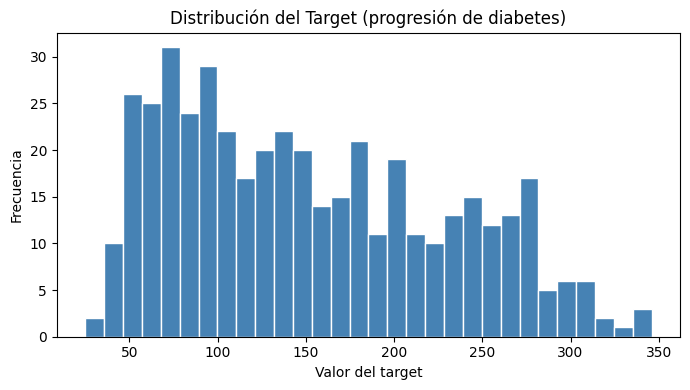

Media: 152.1
Mediana: 140.5
Min: 25 | Max: 346


In [ ]:
# Distribución del target
# Inserta código acá

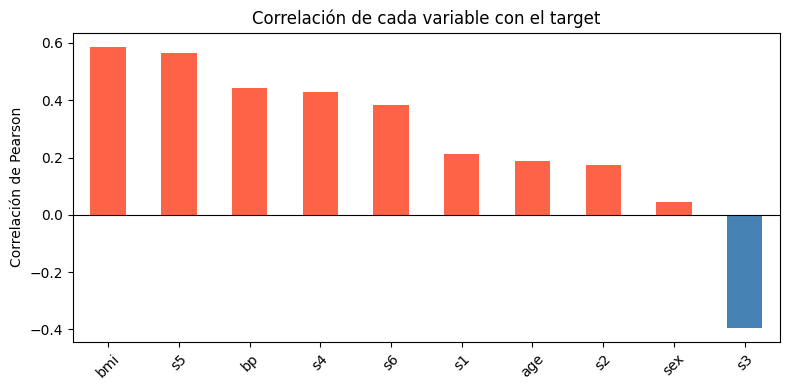

In [ ]:
# Correlación de cada feature con el target
# Esto nos da una idea rápida de cuáles variables son más relevantes


# Inserta código acá)

---
## 3. Selección de Características

### ¿Por qué no basta con tomar las más correlacionadas con el target?

Seleccionar features solo por su correlación con el target tiene un problema: **dos features pueden estar altamente correlacionadas entre sí**, es decir, medir casi lo mismo. Incluir ambas no le da información nueva al modelo — solo ruido y redundancia.

Esto se llama **multicolinealidad** y tiene consecuencias concretas:

| Modelo | Efecto de la multicolinealidad |
|---|---|
| Regresión Lineal | Los coeficientes se vuelven inestables e ininterpretables |
| Árbol / Random Forest | Menor impacto, pero se introduce ruido innecesario |

**Solución simple:** antes de seleccionar features, revisar la **correlación entre ellas** y descartar una de cada par con correlación alta (umbral típico: > 0.85 en valor absoluto).

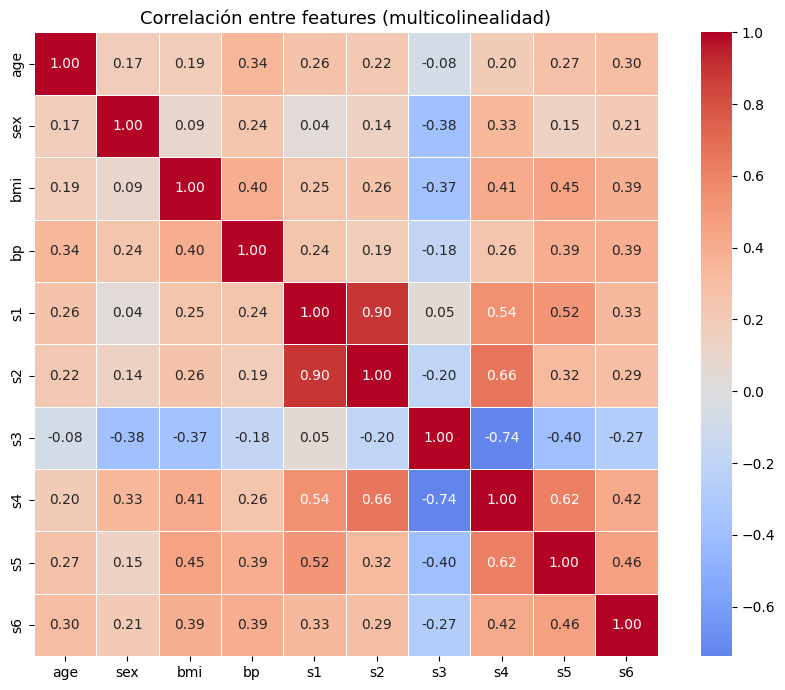

⚠️  Pares con correlación absoluta > 0.85 (posible redundancia):
  s1 ↔ s2: 0.90


In [ ]:
# Heatmap de correlación ENTRE features (excluimos el target)
features_candidatas = df.drop(columns='target')


In [ ]:
# Selección de features: alta correlación con el target + baja entre sí
#
# Algoritmo greedy (paso a paso):
#   1. Ordenar candidatas por correlación absoluta con el target (de mayor a menor)
#   2. Agregar la siguiente candidata SOLO si no está muy correlacionada
#      con ninguna de las ya seleccionadas (umbral = 0.85)
#   3. Parar cuando tengamos 5 features

UMBRAL_MULTI = 0.70   # correlación máxima permitida entre features
N_FEATURES   = 5

candidatas_ordenadas = correlaciones.abs().sort_values(ascending=False).index.tolist()

# Inserta código acá



✅ Features seleccionadas (alta correlación con target, baja entre sí):
  bmi     corr_target = +0.586
  s5      corr_target = +0.566
  bp      corr_target = +0.441
  s4      corr_target = +0.430
  s6      corr_target = +0.382

X shape: (442, 5)
y shape: (442,)


---
## 4. Split Train / Test

Dividimos **antes** de entrenar cualquier modelo.  
El set de test simula datos que el modelo nunca ha visto.

In [ ]:
# Obtención de X y y para el modelado
# Inserta código acá

In [ ]:
# División en train y test
# Inserta código acá

Train: 353 filas
Test:  89 filas


---
## 5. Entrenamiento de Modelos

Entrenamos **3 modelos de regresión** con parámetros simples.

In [ ]:
# Definimos los modelos
modelos = {
    'Regresión Lineal':    LinearRegression(),
    'Árbol de Decisión':   DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest':       RandomForestRegressor(n_estimators=100, random_state=42),
}

# Entrenamos cada uno y guardamos predicciones + tiempos
# Almacena los resultaddos, incluyendo el modelo, las predicciones y los tiempos en un diccionario para compararlos fácilmente

resultados = {}

# Inserta código acá

✅ Todos los modelos entrenados


---
## 6. Evaluación por Métricas

Para regresión usamos tres métricas clave:

| Métrica | ¿Qué mide? | ¿Mejor cuando es...? |
|---|---|---|
| **MAE** | Error absoluto promedio (mismas unidades del target) | Más bajo |
| **RMSE** | Raíz del error cuadrático (penaliza errores grandes) | Más bajo |
| **R²** | % de varianza explicada por el modelo | Más alto (máx = 1.0) |

In [17]:
def calcular_metricas(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2   = r2_score(y_true, y_pred)
    return mae, rmse, r2

# Tabla comparativa: métricas en TRAIN y TEST
print(f"{'Modelo':<22} {'MAE Train':>10} {'MAE Test':>10} {'RMSE Train':>11} {'RMSE Test':>10} {'R² Train':>9} {'R² Test':>9}")
print('─' * 85)

for nombre, r in resultados.items():
    mae_tr, rmse_tr, r2_tr = calcular_metricas(y_train, r['y_pred_train'])
    mae_te, rmse_te, r2_te = calcular_metricas(y_test,  r['y_pred_test'])
    print(f"{nombre:<22} {mae_tr:>10.1f} {mae_te:>10.1f} {rmse_tr:>11.1f} {rmse_te:>10.1f} {r2_tr:>9.3f} {r2_te:>9.3f}")

Modelo                  MAE Train   MAE Test  RMSE Train  RMSE Test  R² Train   R² Test
─────────────────────────────────────────────────────────────────────────────────────
Regresión Lineal             46.3       44.3        55.9       53.8     0.485     0.453
Árbol de Decisión            37.2       45.2        47.5       58.5     0.629     0.353
Random Forest                18.1       45.3        22.3       55.2     0.918     0.425


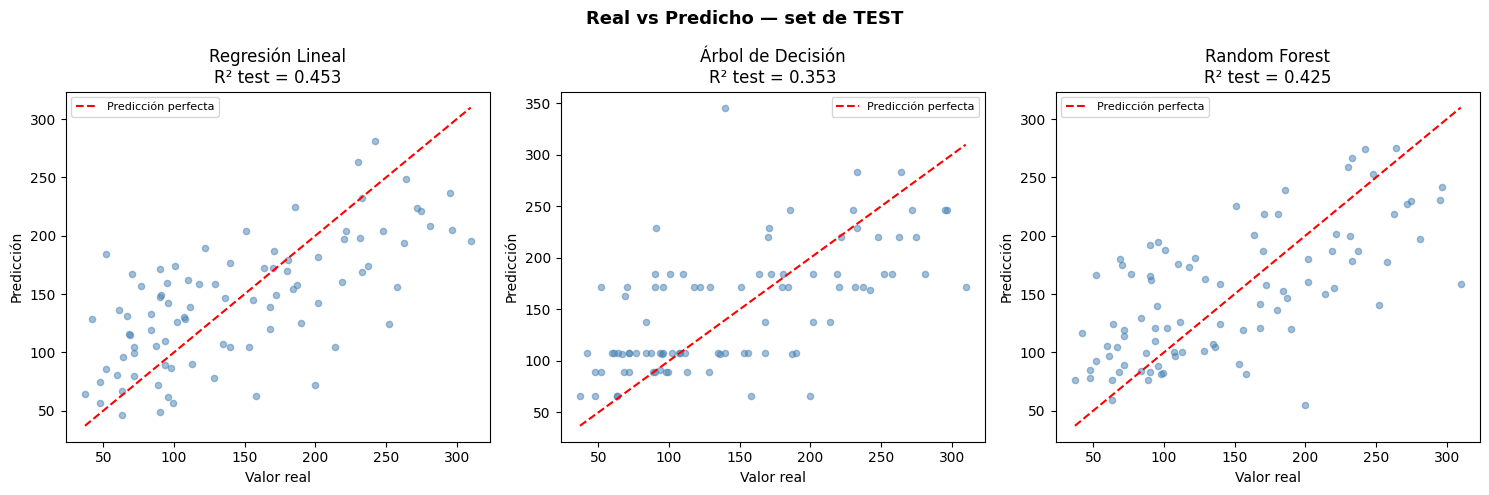

In [18]:
# Visualizar predicciones vs valores reales para cada modelo
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (nombre, r) in zip(axes, resultados.items()):
    y_pred = r['y_pred_test']
    _, _, r2 = calcular_metricas(y_test, y_pred)

    ax.scatter(y_test, y_pred, alpha=0.5, color='steelblue', s=20)

    # Línea perfecta (predicción ideal)
    lim = [y_test.min(), y_test.max()]
    ax.plot(lim, lim, 'r--', linewidth=1.5, label='Predicción perfecta')

    ax.set_xlabel('Valor real')
    ax.set_ylabel('Predicción')
    ax.set_title(f'{nombre}\nR² test = {r2:.3f}')
    ax.legend(fontsize=8)

plt.suptitle('Real vs Predicho — set de TEST', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

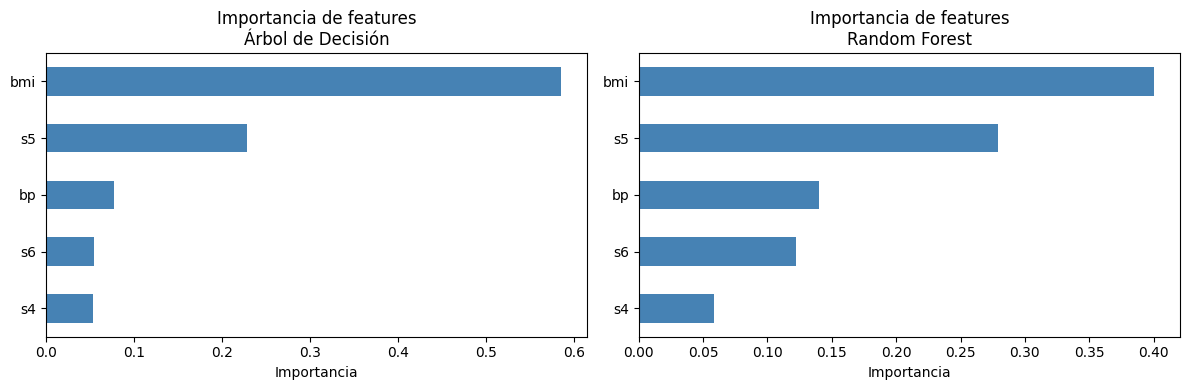

In [19]:
# Importancia de features (solo para los modelos basados en árboles)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, nombre in zip(axes, ['Árbol de Decisión', 'Random Forest']):
    modelo = resultados[nombre]['modelo']
    importancias = pd.Series(modelo.feature_importances_, index=top_features).sort_values()
    importancias.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Importancia de features\n{nombre}')
    ax.set_xlabel('Importancia')

plt.tight_layout()
plt.show()

---
## 7. Comparación por Velocidad

En producción no solo importa qué tan preciso es el modelo,  
sino también **qué tan rápido entrena y predice**.

In [20]:
print(f"{'Modelo':<22} {'Tiempo train':>14} {'Tiempo predict':>16}")
print('─' * 55)

for nombre, r in resultados.items():
    print(f"{nombre:<22} {r['t_train_s']:>12.4f}s {r['t_predict_ms']:>14.2f}ms")

Modelo                   Tiempo train   Tiempo predict
───────────────────────────────────────────────────────
Regresión Lineal             0.0642s           1.56ms
Árbol de Decisión            0.0213s           1.32ms
Random Forest                0.2105s          14.18ms


---
## 8. Guardar el Modelo Ganador y Usarlo con Nuevos Datos

Elegimos el modelo con mejor **R² en test** como ganador.  
Lo guardamos con `joblib` para reutilizarlo sin volver a entrenar.

In [ ]:
modelo_ganador = #Inserta tu código acá

In [23]:
# Guardar el modelo ganador en disco
joblib.dump(modelo_ganador, 'modelo_diabetes_ganador.joblib')

import os
size_kb = os.path.getsize('modelo_diabetes_ganador.joblib') / 1024
print(f"✅ Modelo guardado: 'modelo_diabetes_ganador.joblib' ({size_kb:.1f} KB)")

✅ Modelo guardado: 'modelo_diabetes_ganador.joblib' (0.9 KB)


In [ ]:
# Simular producción: cargar el modelo y predecir sobre datos nuevos
modelo_produccion = joblib.load('modelo_diabetes_ganador.joblib')

# Datos de 4 pacientes nuevos (en el mismo orden que top_features)
# Recuerda: el modelo espera las mismas columnas con las que fue entrenado

nuevos_pacientes = pd.DataFrame({
    feat: [0.05, -0.01, 0.08, -0.03]
    for feat in top_features
})
# Sobreescribimos con valores más realistas para ilustrar variedad
nuevos_pacientes.iloc[0] = [ 0.06,  0.05,  0.07,  0.04,  0.01][:len(top_features)]
nuevos_pacientes.iloc[1] = [-0.05, -0.04, -0.03, -0.02, -0.01][:len(top_features)]
nuevos_pacientes.iloc[2] = [ 0.02,  0.01,  0.03,  0.00,  0.02][:len(top_features)]
nuevos_pacientes.iloc[3] = [ 0.08,  0.07,  0.09,  0.06,  0.05][:len(top_features)]

predicciones_nuevas = modelo_produccion.predict(nuevos_pacientes)

print(f"\n{'Paciente':<12} {'Progresión predicha':>20}")
print('─' * 35)
for i, pred in enumerate(predicciones_nuevas):
    print(f"Paciente {i+1:<4} {pred:>20.1f}")

Features esperadas: ['bmi', 's5', 'bp', 's4', 's6']

Paciente      Progresión predicha
───────────────────────────────────
Paciente 1                   234.6
Paciente 2                    92.4
Paciente 3                   177.8
Paciente 4                   264.6


---
## ✅ Resumen de esta clase

| Paso | ¿Qué hicimos? |
|---|---|
| EDA | Distribución del target, correlaciones, scatter plots |
| Selección de features | Top 5 por correlación con target, descartando multicolinealidad (umbral 0.85) |
| Split | 80% train / 20% test con `train_test_split` |
| Modelos | Regresión Lineal, Árbol de Decisión, Random Forest |
| Métricas | MAE, RMSE y R² — comparados en train Y test |
| Velocidad | Tiempo de `.fit()` y `.predict()` por modelo |
| Producción | `joblib.dump` para guardar, `joblib.load` para reutilizar |

**Próximo sprint:** escalado de features, búsqueda de hiperparámetros con `GridSearchCV`.